In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
sns.set_style("whitegrid")

In [3]:

df = pd.read_csv("multilinear_regression_salary.csv")

print(df.head())
print(df.shape)

   Age  Experience  EducationLevel  Salary
0   24           2               2   52886
1   50           0               4   83518
2   56          18               4  160732
3   60           5               2   85177
4   39           4               3  103664
(1000, 4)


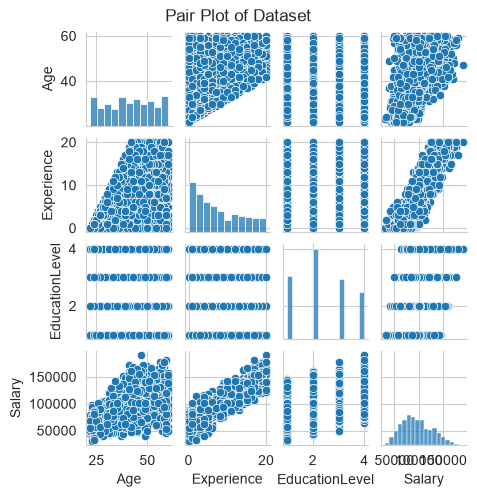

In [6]:
g = sns.pairplot(df, height=1.2, aspect=1)

g.fig.suptitle("Pair Plot of Dataset", y=1.02)
plt.show()

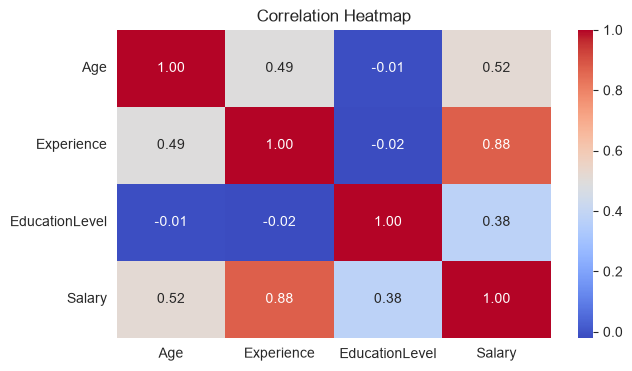

In [8]:
plt.figure(figsize=(7,4))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
X = df[["Age", "Experience", "EducationLevel"]]

y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (800, 3)
Testing Shape : (200, 3)


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Accuracy")
print(model.score(X_test,y_test)*100)

print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Accuracy
93.06546711526342
Intercept:
23680.977940601457

Coefficients:
Age : 317.5049875262954
Experience : 4238.904010715476
EducationLevel : 11748.65935135993


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])



[ 81723.56389121 118461.26542826 145578.01588485  62751.57875032
  58512.6747396  143259.6795175   94520.53965982  77992.79296447
  94424.73820515  69006.85185906]


In [13]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("RMSE     :", round(rmse,2))

R² Score : 0.9307
MAE      : 6408.55
RMSE     : 7770.1


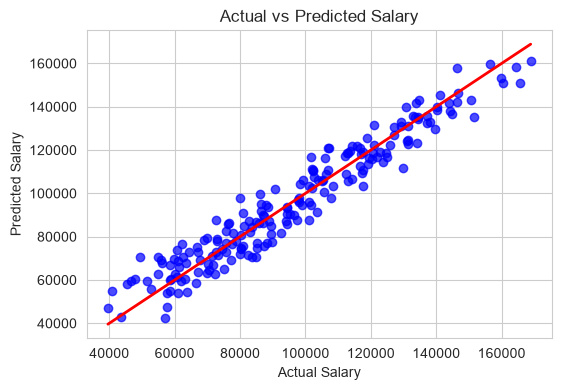

In [18]:
plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    color="blue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

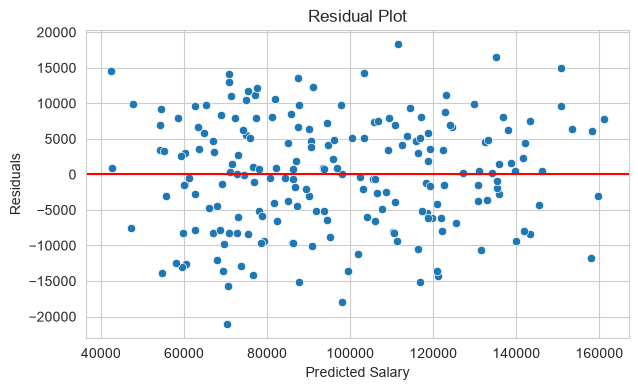

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(7,4))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()